## Chapter 3, P5: Feature Importance in GBM

Once a model is trained, we may ask **"which features are most influential in the model's predictions?"**  

A GBM, despite being an ensemble, is **not a complete black box.** We can inspect it to understand which features are significant drivers of its decisions. This may help:
* Validate the model
* Communicate its findings
* Guide future feature engineering decisions

## How Gradient Boosting Models Measure Importance

In tree-based ensembles, like Gradient Boosting, feature importance is measured based on **how much a feature contributes to reducing the model's loss or impurity.**  

Here's how it works in Scikit-learn (often called "Mean decrease in Impurity"/"Gini Importance"):
1. **Node Impurity:** Each time a tree is built, it splits the data at various nodes. Each split is chosen to maximise the decrease in impurity (e.g., variance for regression, Gini impurity for classification) from the parent node to the two child nodes.  

2. **Importance Score:** The amount of reduction in impurity achieved by a split on a particular feature is that feature's "importance" for that split.

3. **Total Importance:** The sum of these reductions across all splits where that feature was used, aggregated over all trees in the ensemble.

4. **Normalisation:** Finally, these total importance scores are normalised so that they sum to 1.0, making them easier to compare. A feature with a score of 0.30 contributed to 30% of the total impurity reduction across all trees.

A **higher importance score**, based on the above algorithm, means that **feature** was used **more frequently** to make **effective splits**, and thus, the **model relies on it heavily**.

## Accessing Feature Importance with Scikit-learn

We will train a `GradientBoostingRegressor` on a synthetic dataset and then inspect the feature importances.

In [10]:
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor

# Generate a synthetic dataset, making 2 features informative
X, y = make_regression(n_samples=1000, n_features=10, n_informative=2, random_state=42)

# Initialise and train the model
gbr = GradientBoostingRegressor(n_estimators = 100, random_state = 42)
gbr.fit(X, y)

# Access the feature importances
importances = gbr.feature_importances_

# Create a list of feature names for clarity (e.g. [Feature 0, Feature 1, ...])
feature_names = [f'Feature {i}' for i in range(X.shape[1])]

# Print the feature importances
for name, score in zip(feature_names, importances):
    print(f"{name}: {score:.4f}")
    

Feature 0: 0.0000
Feature 1: 0.0844
Feature 2: 0.0000
Feature 3: 0.0000
Feature 4: 0.0000
Feature 5: 0.0000
Feature 6: 0.0000
Feature 7: 0.9154
Feature 8: 0.0000
Feature 9: 0.0000


* The GBM found that two features (feature 1, feature 7) were important (i.e. they were **used frequently** to make **effective splits**, and thus, the **model relied on these two features heavily**).
* This aligns with our `make_regression()` definition, where we set `n_informative = 2`, defining two important features.

## Visualising Feature Importance

A horizontal bar chart is an effective way to visualize and compare the relative importance of each feature.

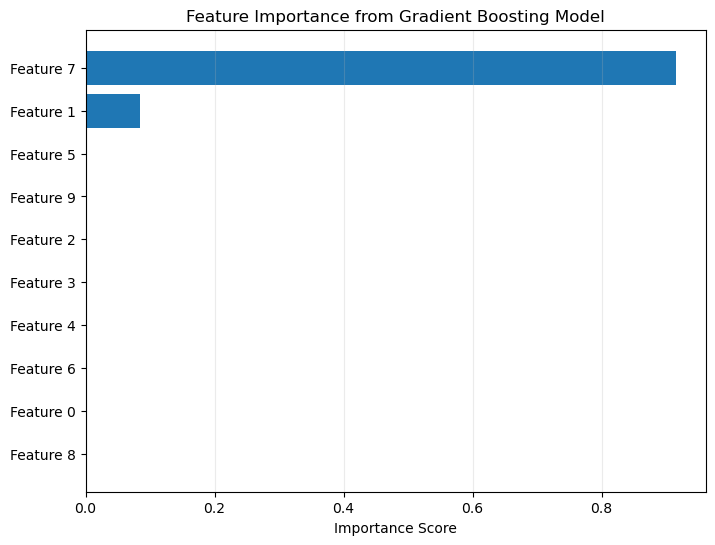

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Sort features by importance (descending)
indices = np.argsort(importances)[::-1]
sorted_importances = importances[indices]
sorted_features = [feature_names[i] for i in indices]

# Create the plot
plt.figure(figsize=(8, 6))

plt.barh(
    sorted_features,
    sorted_importances
)

plt.gca().invert_yaxis()  # Most important feature at the top
plt.xlabel("Importance Score")
plt.title("Feature Importance from Gradient Boosting Model")
plt.grid(axis="x", alpha=0.25)

plt.show()

## Important Limitations to Feature Importance

While feature importance is a valuable tool, it's important to be aware of its limitations.

* **Bias Towards High Cardinality Features:** Tree-based models can sometimes assign higher importance to features with **many unique values**. This is because these features **offer more potential split points**, increasing the chances of finding a split that reduces impurity.  

* **Correlated Features:** If **two or more features are highly correlated, they might act as substitutes for each other.** When the model builds its trees, it might pick one of them for a split, and its importance score will increase. The other correlated features might not be selected as often, leading to lower importance scores. **The total importance of the underlying signal carried by these features gets diluted across them, potentially misleading you to think the signal is weaker than it is.**  

* **Importance Does Not Imply Direction:** Feature importance tells you how much a feature matters, but **not how it matters.** For instance, a high importance score for "house_age" does not tell you whether older houses have higher or lower prices. It only tells you that "house_age" is a strong predictor. **To understand the relationship between a feature and the prediction**, we need other tools, such as the **Partial Dependence Plots** we will discuss in the next section.